In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split

In [6]:

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


In [7]:

df = pd.read_csv("fraudTest.csv")
df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,Luray,MO,63453,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
555715,555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,Lake Jackson,TX,77566,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
555716,555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,Burbank,WA,99323,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
555717,555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,Mesa,ID,83643,44.6255,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0


In [8]:
df.shape[0]

555719

In [9]:
df.shape[1]

23

In [10]:
df.head(10)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0
5,5,2020-06-21 12:15:37,30407675418785,fraud_Daugherty LLC,kids_pets,19.55,Danielle,Evans,F,76752 David Lodge Apt. 064,Breesport,NY,14816,42.1939,-76.7361,520,Psychotherapist,1991-10-13,798db04aaceb4febd084f1a7c404da93,1371816937,41.747157,-77.584197,0
6,6,2020-06-21 12:15:44,213180742685905,fraud_Romaguera Ltd,health_fitness,133.93,Kayla,Sutton,F,010 Weaver Land,Carlotta,CA,95528,40.5070,-123.9743,1139,"Therapist, occupational",1951-01-15,17003d7ce534440eadb10c4750e020e5,1371816944,41.499458,-124.888729,0
7,7,2020-06-21 12:15:50,3589289942931264,fraud_Reichel LLC,personal_care,10.37,Paula,Estrada,F,350 Stacy Glens,Spencer,SD,57374,43.7557,-97.5936,343,"Development worker, international aid",1972-03-05,8be473af4f05fc6146ea55ace73e7ca2,1371816950,44.495498,-97.728453,0
8,8,2020-06-21 12:16:10,3596357274378601,"fraud_Goyette, Howell and Collier",shopping_pos,4.37,David,Everett,M,4138 David Fall,Morrisdale,PA,16858,41.0001,-78.2357,3688,Advice worker,1973-05-27,71a1da150d1ce510193d7622e08e784e,1371816970,41.546067,-78.120238,0
9,9,2020-06-21 12:16:11,3546897637165774,fraud_Kilback Group,food_dining,66.54,Kayla,Obrien,F,7921 Robert Port Suite 343,Prairie Hill,TX,76678,31.6591,-96.8094,263,Barrister,1956-05-30,a7915132c7c4240996ba03a47f81e3bd,1371816971,31.782919,-96.366185,0


In [11]:
df.tail(10)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
555709,555709,2020-12-31 23:57:18,30344654314976,"fraud_Larkin, Stracke and Greenfelder",entertainment,46.71,Christine,Johnson,F,8011 Chapman Tunnel Apt. 568,Blairsden-Graeagle,CA,96103,39.8127,-120.6405,1725,Chartered legal executive (England and Wales),1967-05-27,a7105564935ea3977dc61ff9ced3bf5e,1388534238,38.963543,-120.457121,0
555710,555710,2020-12-31 23:57:50,3524574586339330,"fraud_Heathcote, Yost and Kertzmann",shopping_net,29.56,Ashley,Cabrera,F,94225 Smith Springs Apt. 617,Vero Beach,FL,32960,27.6330,-80.4031,105638,"Librarian, public",1986-05-07,9fc9f6f9be3182d519a61a119cf97199,1388534270,27.593881,-80.855092,0
555711,555711,2020-12-31 23:57:56,341546199006537,fraud_Schmidt-Larkin,home,12.68,Mark,Brown,M,8580 Moore Cove,Wales,AK,99783,64.7556,-165.6723,145,"Administrator, education",1939-11-09,a8310343c189e4a5b6316050d2d6b014,1388534276,65.623593,-165.186033,0
555712,555712,2020-12-31 23:58:04,501802953619,"fraud_Pouros, Walker and Spencer",kids_pets,13.02,Robert,Flores,M,3277 Fields Meadows Apt. 790,Greenview,CA,96037,41.5403,-122.9366,308,Call centre manager,1958-09-20,bd7071fd5c9510a5594ee196368ac80e,1388534284,41.973127,-123.553032,0
555713,555713,2020-12-31 23:58:34,3523843138706408,"fraud_Prosacco, Kreiger and Kovacek",home,17.00,Grace,Williams,F,28812 Charles Mill Apt. 628,Plantersville,AL,36758,32.6176,-86.9475,1412,Drilling engineer,1970-11-20,6d04313bfe4b661b8ca2b6a499a320fe,1388534314,32.164145,-87.539669,0
555714,555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,Luray,MO,63453,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
555715,555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,Lake Jackson,TX,77566,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
555716,555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,Burbank,WA,99323,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
555717,555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,Mesa,ID,83643,44.6255,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0
555718,555718,2020-12-31 23:59:34,4170689372027579,fraud_Dare-Marvin,entertainment,38.13,Samuel,Frey,M,830 Myers Plaza Apt. 384,Edmond,OK,73034,35.6665,-97.4798,116001,Media buyer,1993-05-10,1765bb45b3aa3224b4cdcb6e7a96cee3,1388534374,36.210097,-97.036372,0


In [12]:
df.shape

(555719, 23)

In [13]:
df.columns.tolist()

['Unnamed: 0',
 'trans_date_trans_time',
 'cc_num',
 'merchant',
 'category',
 'amt',
 'first',
 'last',
 'gender',
 'street',
 'city',
 'state',
 'zip',
 'lat',
 'long',
 'city_pop',
 'job',
 'dob',
 'trans_num',
 'unix_time',
 'merch_lat',
 'merch_long',
 'is_fraud']

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  str    
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  str    
 4   category               555719 non-null  str    
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  str    
 7   last                   555719 non-null  str    
 8   gender                 555719 non-null  str    
 9   street                 555719 non-null  str    
 10  city                   555719 non-null  str    
 11  state                  555719 non-null  str    
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-null  float64

In [15]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,555719.0,2.778590e+05,1.604224e+05,0.000000e+00,1.389295e+05,2.778590e+05,4.167885e+05,5.557180e+05
cc_num,555719.0,4.178387e+17,1.309837e+18,6.041621e+10,1.800429e+14,3.521417e+15,4.635331e+15,4.992346e+18
amt,555719.0,6.939281e+01,1.567459e+02,1.000000e+00,9.630000e+00,4.729000e+01,8.301000e+01,2.276811e+04
zip,555719.0,4.884263e+04,2.685528e+04,1.257000e+03,2.629200e+04,4.817400e+04,7.201100e+04,9.992100e+04
lat,555719.0,3.854325e+01,5.061336e+00,2.002710e+01,3.466890e+01,3.937160e+01,4.189480e+01,6.568990e+01
long,555719.0,-9.023133e+01,1.372178e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.017520e+01,-6.795030e+01
city_pop,555719.0,8.822189e+04,3.003909e+05,2.300000e+01,7.410000e+02,2.408000e+03,1.968500e+04,2.906700e+06
unix_time,555719.0,1.380679e+09,5.201104e+06,1.371817e+09,1.376029e+09,1.380762e+09,1.385867e+09,1.388534e+09
merch_lat,555719.0,3.854280e+01,5.095829e+00,1.902742e+01,3.475530e+01,3.937659e+01,4.195416e+01,6.667930e+01
merch_long,555719.0,-9.023138e+01,1.373307e+01,-1.666716e+02,-9.690513e+01,-8.744520e+01,-8.026464e+01,-6.695203e+01


In [17]:
df.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:


print(df["is_fraud"].value_counts())

is_fraud
0    553574
1      2145
Name: count, dtype: int64


In [20]:
print(df['is_fraud'].value_counts(normalize=True) * 100)

is_fraud
0    99.614014
1     0.385986
Name: proportion, dtype: float64


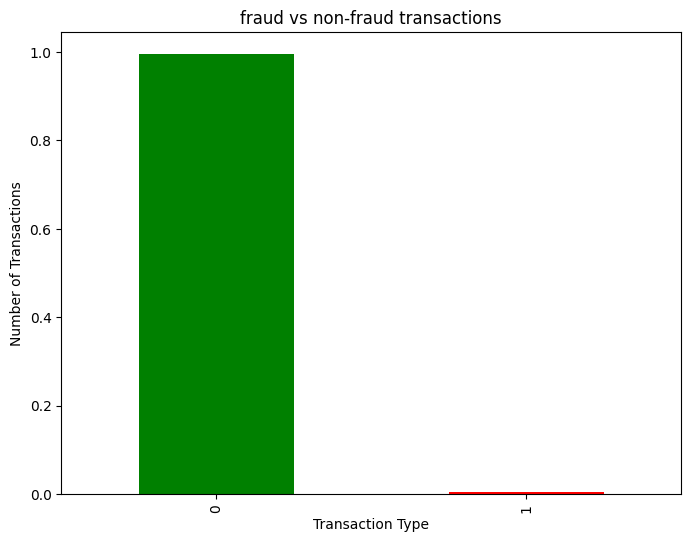

In [21]:
df['is_fraud'].value_counts(normalize=True).plot(kind='bar',color=['green','red'], figsize=(8,6))
plt.title('fraud vs non-fraud transactions')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.show()

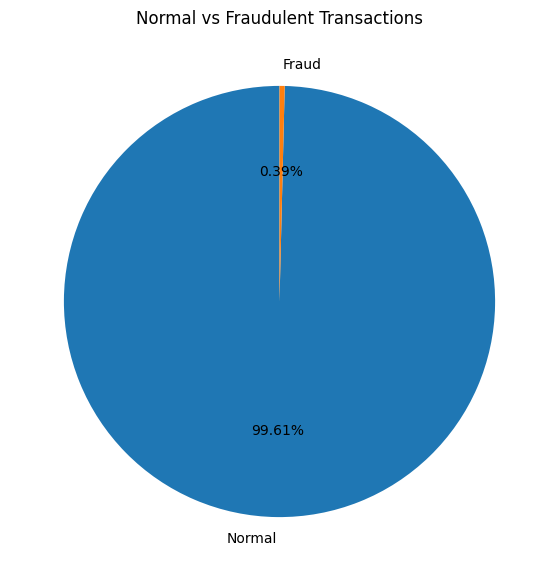

In [22]:
# Fraud vs Normal - Pie Chart

fraud_counts = df["is_fraud"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    fraud_counts,
    labels=["Normal", "Fraud"],
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Normal vs Fraudulent Transactions")

plt.show()

In [23]:
df["amt"].describe()

count    555719.000000
mean         69.392810
std         156.745941
min           1.000000
25%           9.630000
50%          47.290000
75%          83.010000
max       22768.110000
Name: amt, dtype: float64

In [24]:
df.groupby("is_fraud")["amt"].mean()

is_fraud
0     67.614408
1    528.356494
Name: amt, dtype: float64

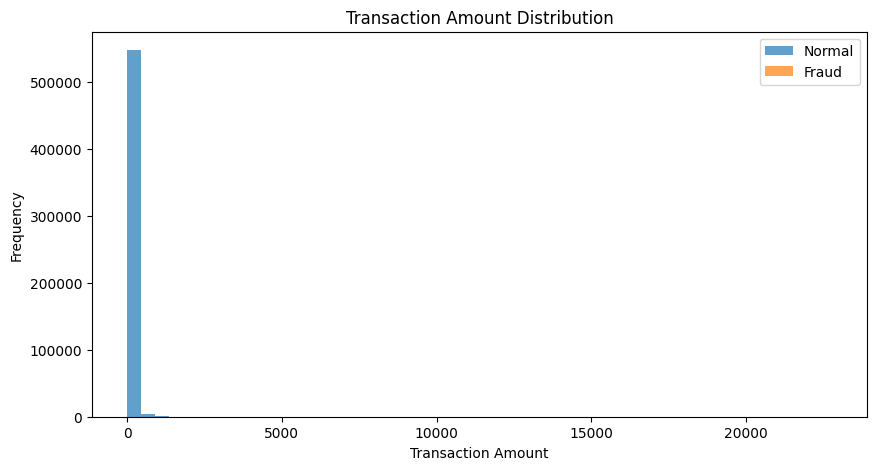

In [25]:

plt.figure(figsize=(10, 5))

plt.hist(
    df[df["is_fraud"] == 0]["amt"],
    bins=50,
    alpha=0.7,
    label="Normal"
)

plt.hist(
    df[df["is_fraud"] == 1]["amt"],
    bins=50,
    alpha=0.7,
    label="Fraud"
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.legend()

plt.show()

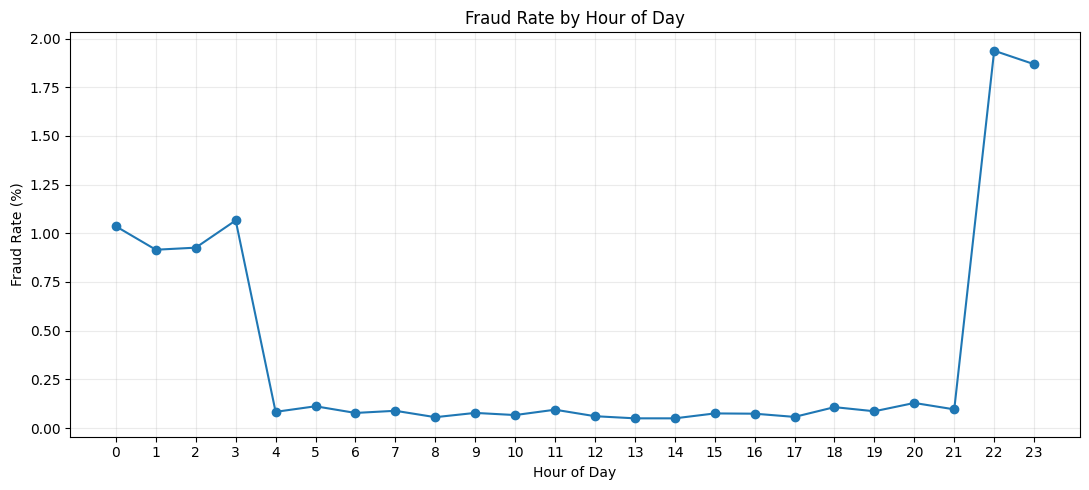

In [26]:


df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["hour"] = df["trans_date_trans_time"].dt.hour

hourly_fraud = (
    df.groupby("hour")["is_fraud"]
      .mean()
      .mul(100)
)

plt.figure(figsize=(11, 5))
plt.plot(hourly_fraud.index, hourly_fraud.values, marker="o")

plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

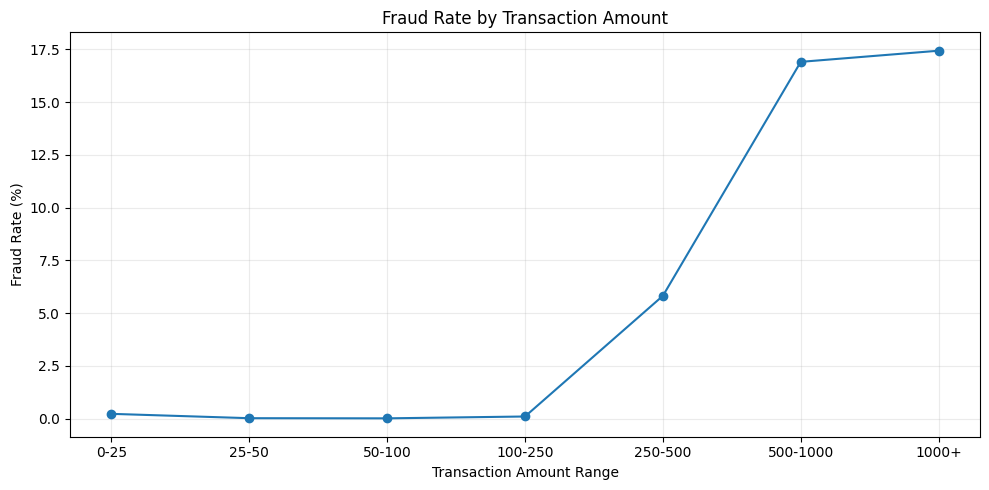

In [27]:


bins = [0, 25, 50, 100, 250, 500, 1000, float("inf")]
labels = ["0-25", "25-50", "50-100", "100-250",
          "250-500", "500-1000", "1000+"]

df["amount_range"] = pd.cut(
    df["amt"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

fraud_rate = (
    df.groupby("amount_range", observed=True)["is_fraud"]
      .mean()
      .mul(100)
)

plt.figure(figsize=(10, 5))
plt.plot(
    fraud_rate.index.astype(str),
    fraud_rate.values,
    marker="o"
)

plt.title("Fraud Rate by Transaction Amount")
plt.xlabel("Transaction Amount Range")
plt.ylabel("Fraud Rate (%)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

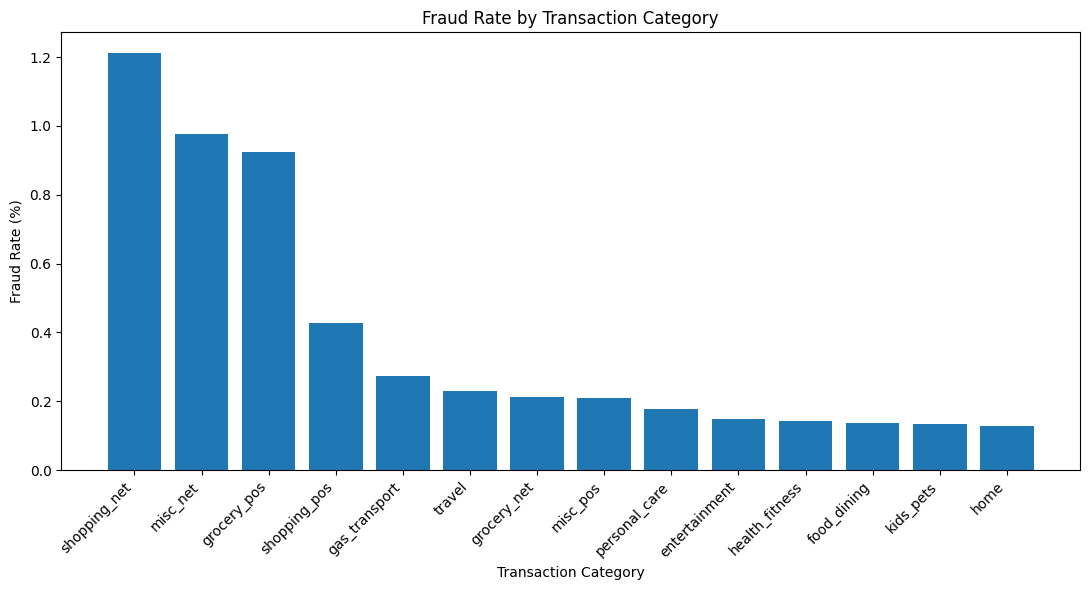

In [28]:

category_fraud = (
    df.groupby("category")["is_fraud"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))
plt.bar(
    category_fraud.index,
    category_fraud.values
)

plt.title("Fraud Rate by Transaction Category")
plt.xlabel("Transaction Category")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

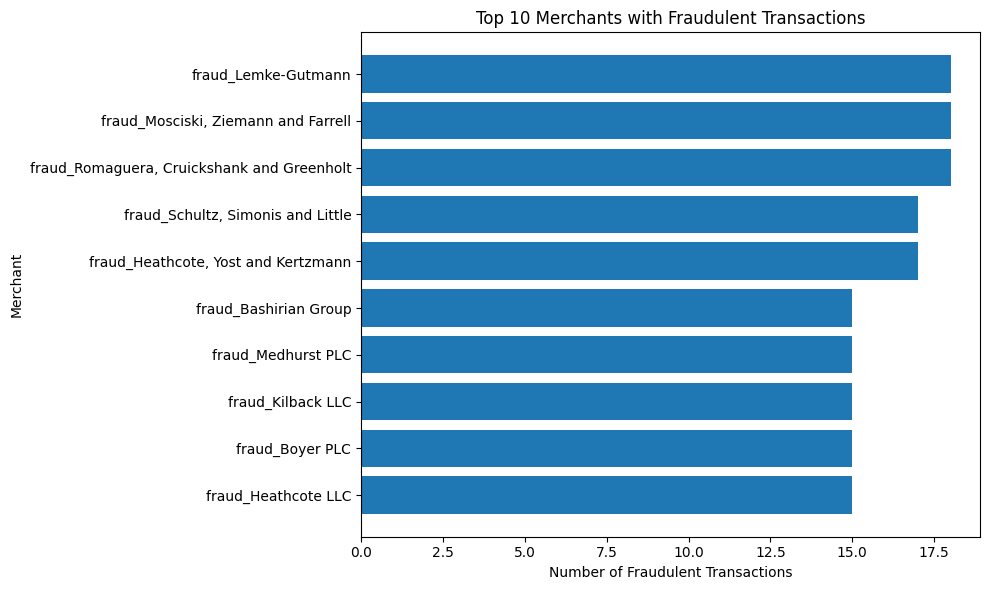

In [29]:


top_merchants = (
    df[df["is_fraud"] == 1]["merchant"]
      .value_counts()
      .head(10)
      .sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_merchants.index,
    top_merchants.values
)

plt.title("Top 10 Merchants with Fraudulent Transactions")
plt.xlabel("Number of Fraudulent Transactions")
plt.ylabel("Merchant")
plt.tight_layout()
plt.show()

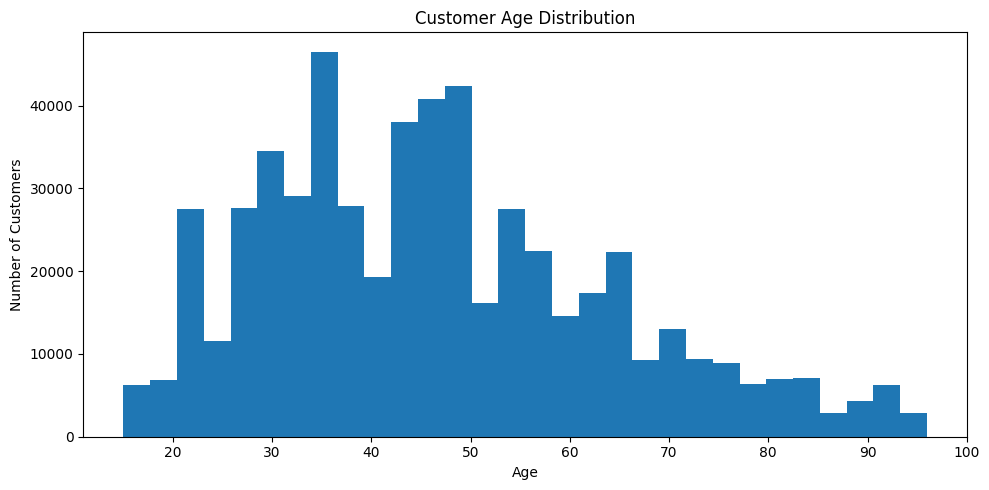

In [30]:

df["dob"] = pd.to_datetime(df["dob"])

reference_date = df["trans_date_trans_time"].max()

df["age"] = (
    reference_date.year - df["dob"].dt.year
)

plt.figure(figsize=(10, 5))
plt.hist(
    df["age"],
    bins=30
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

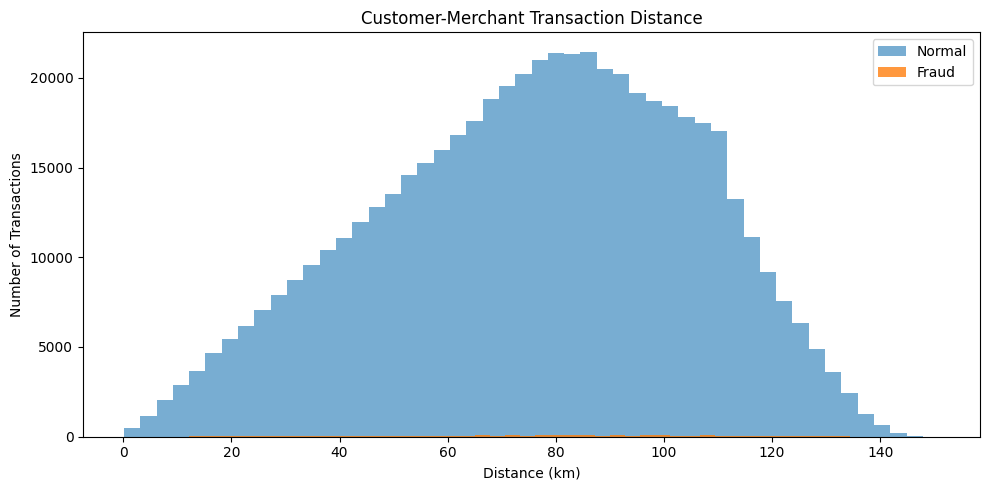

In [31]:
# ============================================================
# Step 11: Customer-Merchant Distance
# ============================================================

import numpy as np

lat_diff = np.radians(df["merch_lat"] - df["lat"])
lon_diff = np.radians(df["merch_long"] - df["long"])

a = (
    np.sin(lat_diff / 2) ** 2
    + np.cos(np.radians(df["lat"]))
    * np.cos(np.radians(df["merch_lat"]))
    * np.sin(lon_diff / 2) ** 2
)

df["distance_km"] = (
    6371 * 2 * np.arcsin(np.sqrt(a))
)

plt.figure(figsize=(10, 5))

plt.hist(
    df.loc[df["is_fraud"] == 0, "distance_km"],
    bins=50,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    df.loc[df["is_fraud"] == 1, "distance_km"],
    bins=50,
    alpha=0.8,
    label="Fraud"
)

plt.title("Customer-Merchant Transaction Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Number of Transactions")
plt.legend()
plt.tight_layout()
plt.show()

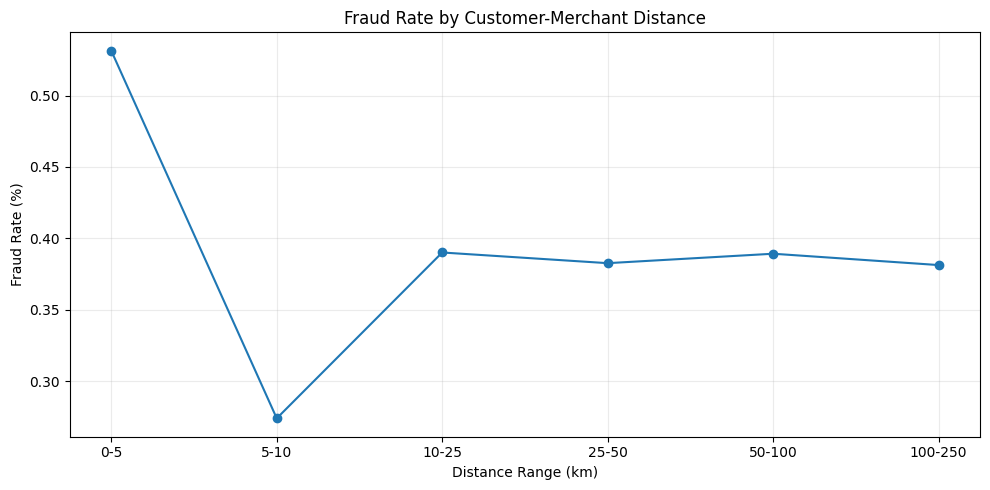

In [32]:

distance_bins = [0, 5, 10, 25, 50, 100, 250, 500, float("inf")]

distance_labels = [
    "0-5", "5-10", "10-25", "25-50",
    "50-100", "100-250", "250-500", "500+"
]

df["distance_range"] = pd.cut(
    df["distance_km"],
    bins=distance_bins,
    labels=distance_labels,
    include_lowest=True
)

distance_fraud = (
    df.groupby("distance_range", observed=True)["is_fraud"]
      .mean()
      .mul(100)
)

plt.figure(figsize=(10, 5))

plt.plot(
    distance_fraud.index.astype(str),
    distance_fraud.values,
    marker="o"
)

plt.title("Fraud Rate by Customer-Merchant Distance")
plt.xlabel("Distance Range (km)")
plt.ylabel("Fraud Rate (%)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

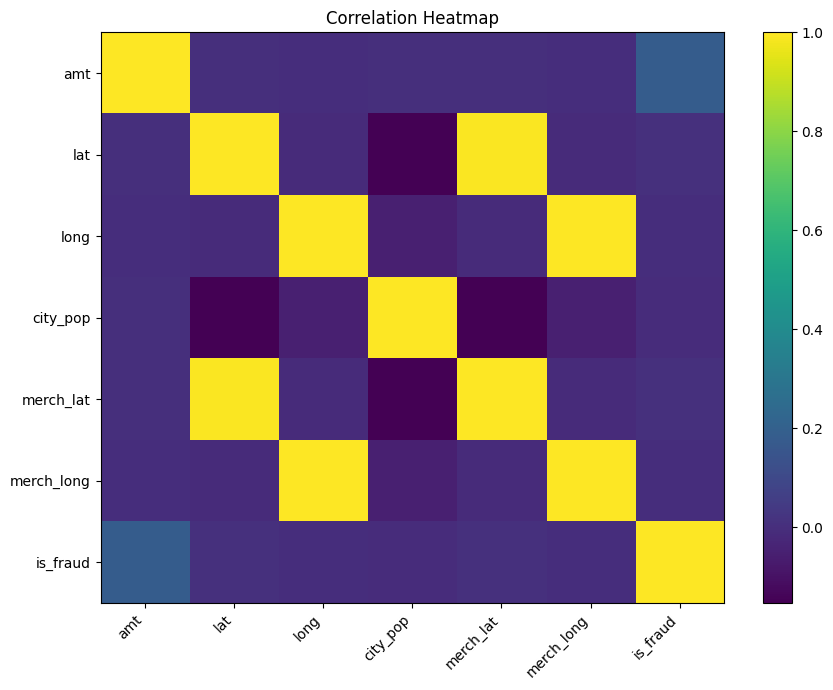

In [33]:

numeric_cols = [
    "amt",
    "lat",
    "long",
    "city_pop",
    "merch_lat",
    "merch_long",
    "is_fraud"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))

plt.imshow(corr, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [34]:

drop_cols = [
    "is_fraud",
    "trans_num",
    "trans_date_trans_time",
    "cc_num",
    "first",
    "last",
    "street",
    "city",
    "zip",
    "merchant",
    "job",
    "dob",
    "category",
    "state",
    "amount_range",
    "distance_range"
]

X = df.drop(columns=drop_cols, errors="ignore")
y = df["is_fraud"]

print("Features:", X.shape)
print("Target:", y.shape)
print("\nTarget Distribution:")
print(y.value_counts())

Features: (555719, 12)
Target: (555719,)

Target Distribution:
is_fraud
0    553574
1      2145
Name: count, dtype: int64


In [35]:
missing = X.isnull().sum()
missing

Unnamed: 0     0
amt            0
gender         0
lat            0
long           0
city_pop       0
unix_time      0
merch_lat      0
merch_long     0
hour           0
age            0
distance_km    0
dtype: int64

In [36]:
print("Numerical Features:")
(X.select_dtypes(include="number").columns.tolist())


Numerical Features:


['Unnamed: 0',
 'amt',
 'lat',
 'long',
 'city_pop',
 'unix_time',
 'merch_lat',
 'merch_long',
 'hour',
 'age',
 'distance_km']

In [37]:
print("\nCategorical Features:")
X.select_dtypes(exclude="number").columns.tolist()


Categorical Features:


['gender']

In [38]:

# Separate numerical and categorical features
num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(exclude="number").columns

# One-Hot Encoding
encoder = OneHotEncoder(handle_unknown="ignore")

X_cat = encoder.fit_transform(X[cat_cols])
X_num = X[num_cols].values

# Combine features
X_encoded = hstack([X_num, X_cat])

# Stratified split because fraud data is imbalanced
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)
print("Train Fraud Rate:", y_train.mean())
print("Test Fraud Rate :", y_test.mean())

Training Shape: (444575, 13)
Testing Shape : (111144, 13)
Train Fraud Rate: 0.003859866164314233
Test Fraud Rate : 0.003859857482185273


In [39]:
# ============================================================
# Step 16: Logistic Regression Baseline
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

model_lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)
y_prob = model_lr.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print("-" * 35)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Logistic Regression Results
-----------------------------------
Accuracy : 0.9506
Precision: 0.0554
Recall   : 0.7343
F1 Score : 0.1030
ROC-AUC  : 0.8413


In [40]:
# ============================================================
# Step 16.1: Classification Report
# ============================================================

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Fraud"]
))

              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97    110715
       Fraud       0.06      0.73      0.10       429

    accuracy                           0.95    111144
   macro avg       0.53      0.84      0.54    111144
weighted avg       1.00      0.95      0.97    111144



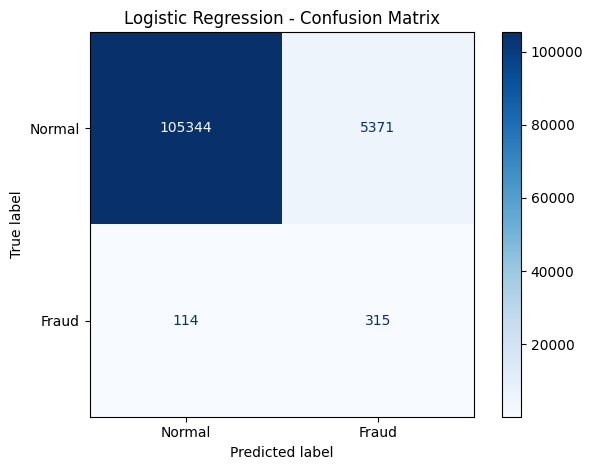

In [41]:
# ============================================================
# Step 16.2: Confusion Matrix
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Normal", "Fraud"],
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

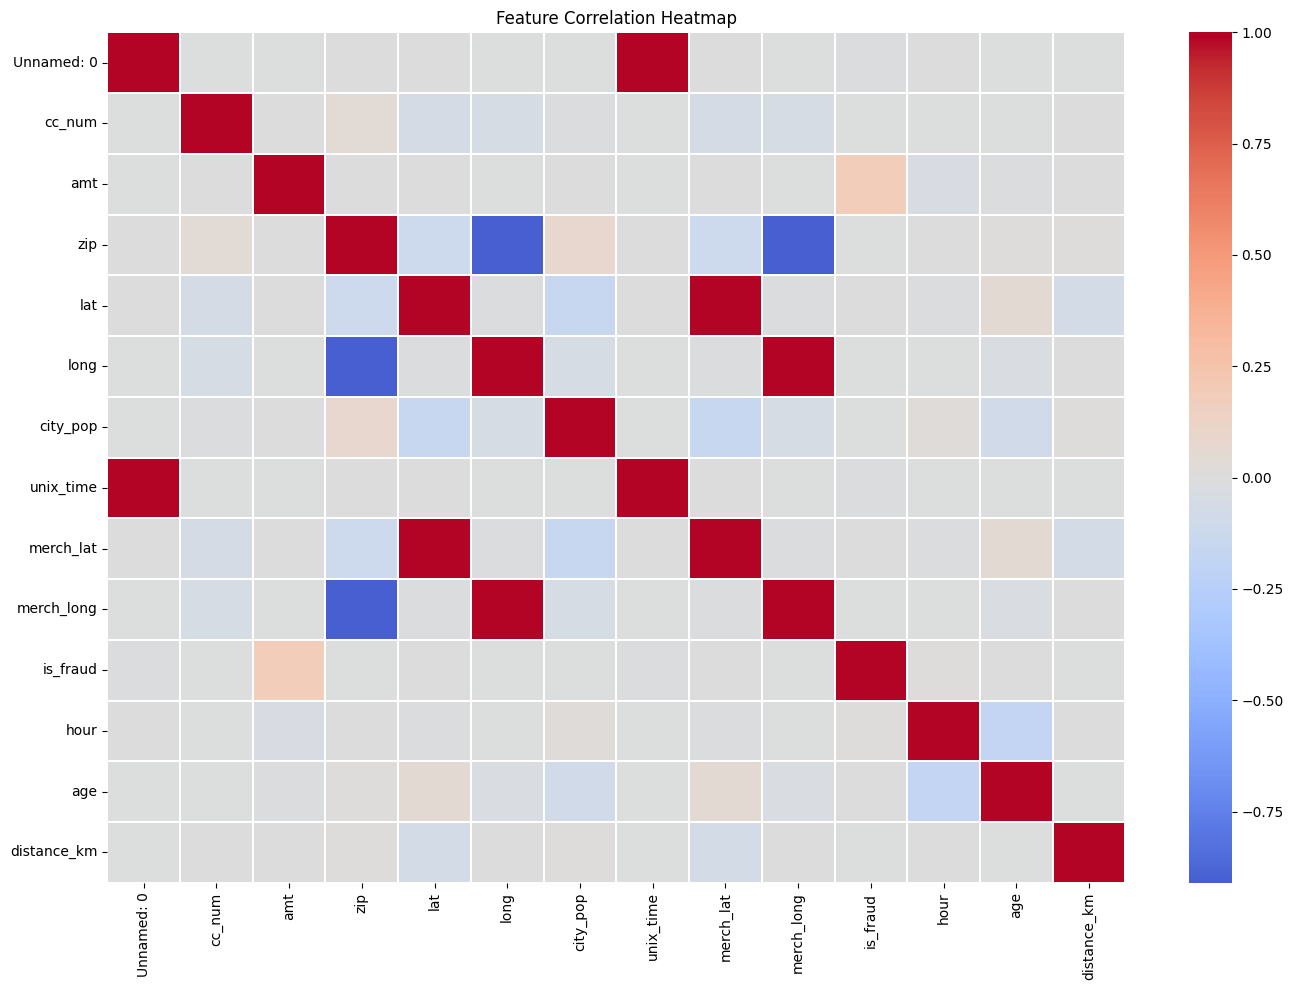

In [42]:
# ============================================================
# Step 17: Correlation Analysis
# ============================================================

import seaborn as sns

corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [43]:
# ============================================================
# Step 17.1: Correlation with Fraud
# ============================================================

target = "is_fraud"

target_corr = (
    corr[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

display(target_corr.head(15))

amt            0.182267
Unnamed: 0    -0.013892
unix_time     -0.013066
hour           0.011686
age            0.007513
lat            0.005863
merch_lat      0.005812
city_pop      -0.004910
zip           -0.002271
cc_num        -0.001540
merch_long    -0.001060
long          -0.000972
distance_km    0.000233
Name: is_fraud, dtype: float64

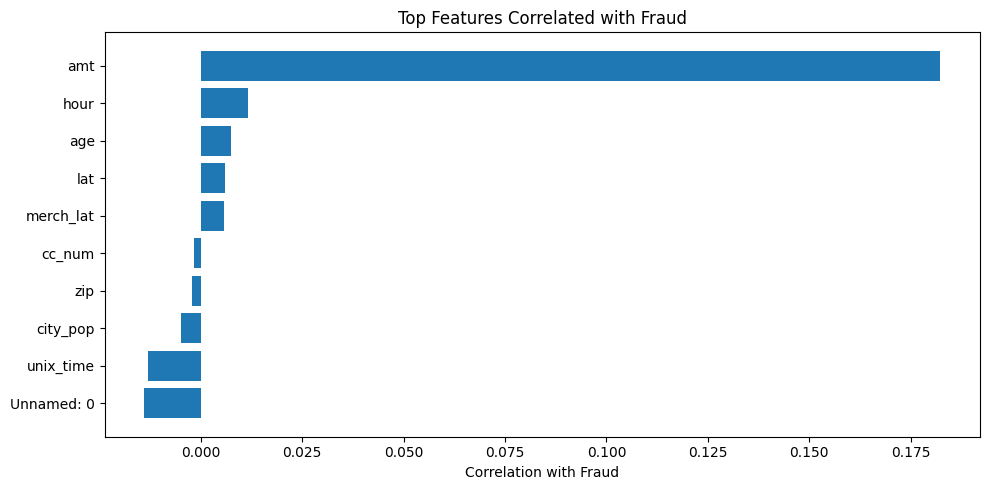

In [44]:
# ============================================================
# Step 17.2: Top Features Correlated with Fraud
# ============================================================

top_corr = target_corr.head(10).sort_values()

plt.figure(figsize=(10, 5))

plt.barh(top_corr.index, top_corr.values)

plt.title("Top Features Correlated with Fraud")
plt.xlabel("Correlation with Fraud")
plt.tight_layout()
plt.show()

In [45]:
# ============================================================
# Step 18: Fraud vs Legitimate Feature Comparison
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical features
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Remove target
numeric_cols = [col for col in numeric_cols if col != "is_fraud"]

# Mean comparison
comparison = df.groupby("is_fraud")[numeric_cols].mean()

# Transpose for easy comparison
comparison = comparison.T

display(comparison.head(10))

is_fraud,0,1
Unnamed: 0,2.779977e+05,2.420571e+05
cc_num,4.179643e+17,3.854274e+17
amt,6.761441e+01,5.283565e+02
zip,4.884642e+04,4.786290e+04
lat,3.854141e+01,3.901997e+01
long,-9.023049e+01,-9.044556e+01
city_pop,8.831369e+04,6.452932e+04
unix_time,1.380683e+09,1.379587e+09
merch_lat,3.854095e+01,3.901862e+01
merch_long,-9.023047e+01,-9.046522e+01


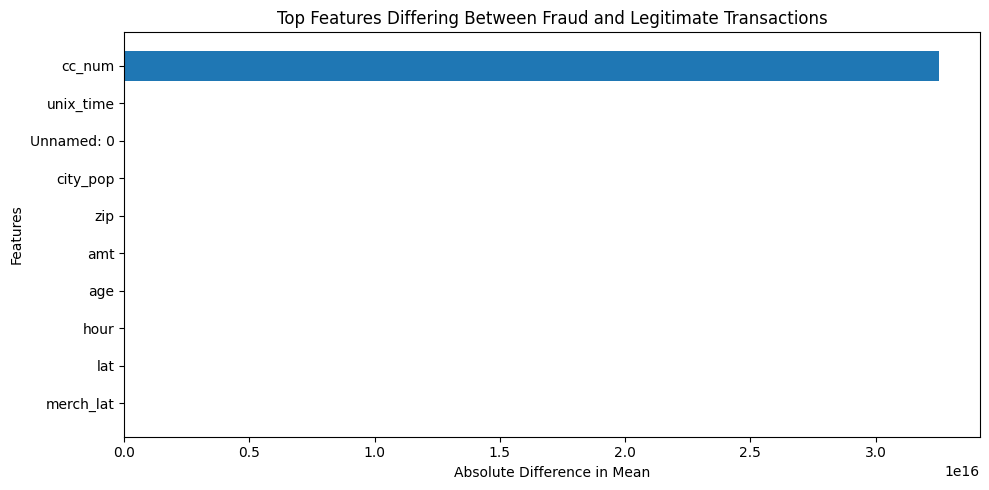

In [46]:
# ============================================================
# Step 18.2: Feature Difference Visualization
# ============================================================

# Calculate mean difference
comparison = df.groupby("is_fraud").mean(numeric_only=True).T

# Remove target column if present
comparison = comparison.drop("is_fraud", errors="ignore")

# Calculate absolute difference
diff = (
    comparison[1] - comparison[0]
).abs().sort_values(ascending=False)

# Select top 10 features
top_features = diff.head(10)

# Plot
plt.figure(figsize=(10, 5))

plt.barh(
    top_features.index[::-1],
    top_features.values[::-1]
)

plt.title("Top Features Differing Between Fraud and Legitimate Transactions")
plt.xlabel("Absolute Difference in Mean")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

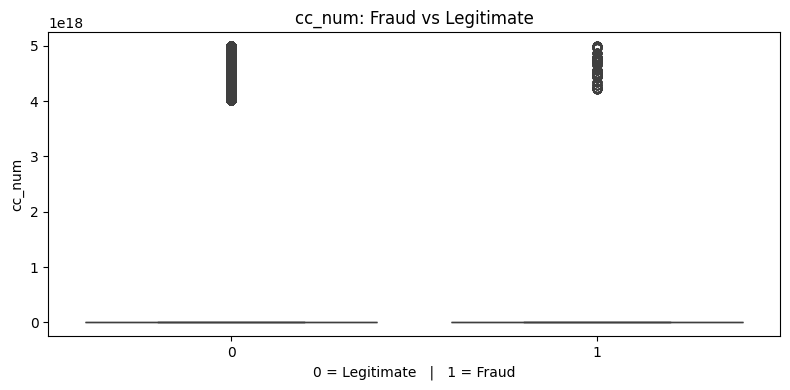

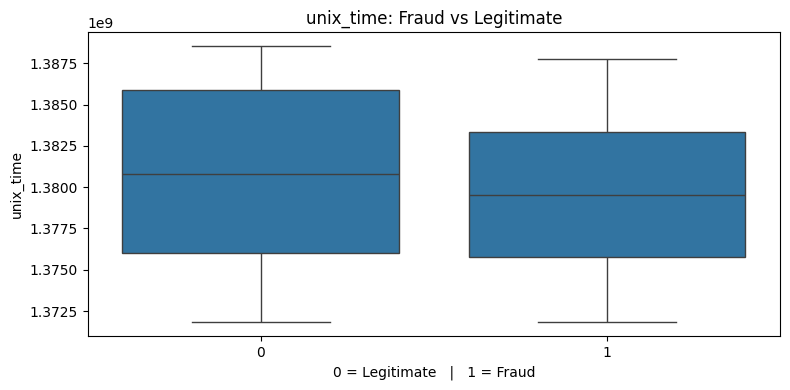

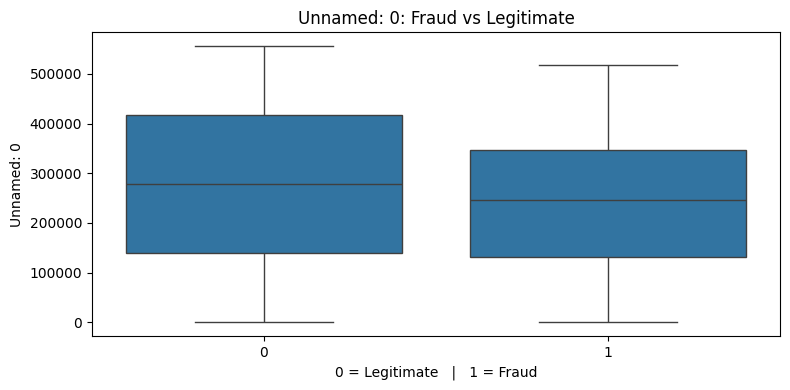

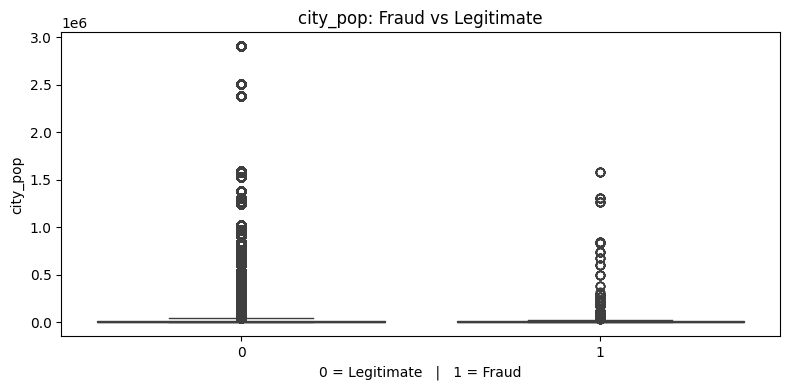

In [47]:
# ============================================================
# Step 18.3: Fraud vs Legitimate Distribution
# ============================================================

top_features = (
    df.groupby("is_fraud")
      .mean(numeric_only=True)
      .T
      .drop("is_fraud", errors="ignore")
      .pipe(lambda x: (x[1] - x[0]).abs())
      .sort_values(ascending=False)
      .head(4)
)

for feature in top_features.index:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        data=df,
        x="is_fraud",
        y=feature
    )

    plt.title(f"{feature}: Fraud vs Legitimate")
    plt.xlabel("0 = Legitimate   |   1 = Fraud")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

In [48]:
display(
    fraud_rate.to_frame("Fraud Rate (%)")
)

,Fraud Rate (%)
amount_range,
0-25,0.224041
25-50,0.017806
50-100,0.010791
100-250,0.098199
250-500,5.817794
500-1000,16.907675
1000+,17.435250


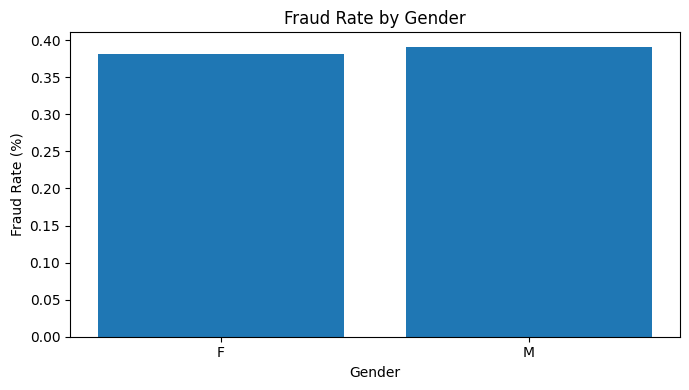

In [49]:
gender_fraud = (
    pd.crosstab(
        df["gender"],
        df["is_fraud"],
        normalize="index"
    ) * 100
)

plt.figure(figsize=(7, 4))

plt.bar(
    gender_fraud.index,
    gender_fraud[1]
)

plt.title("Fraud Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

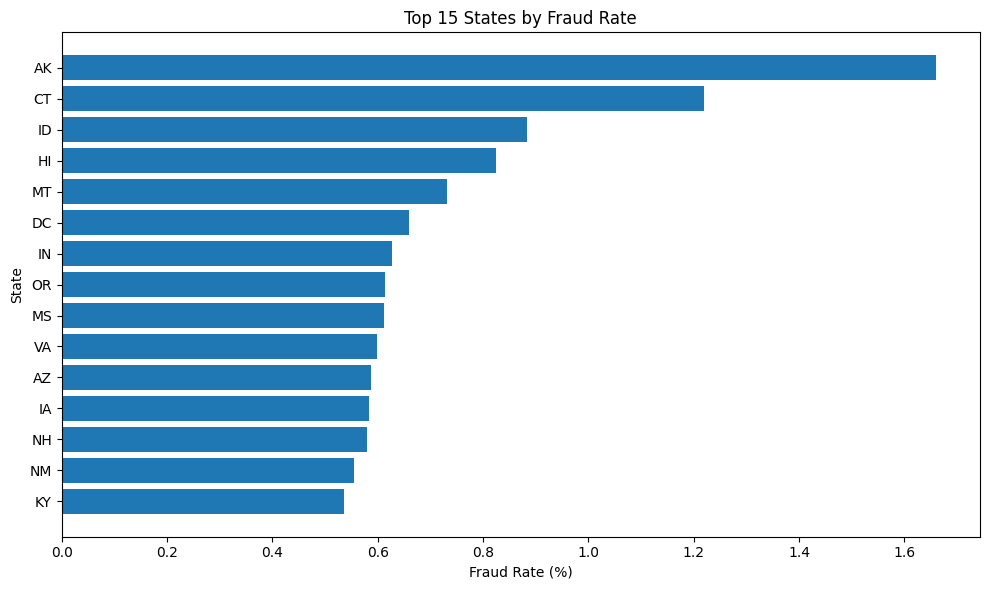

In [50]:
# ============================================================
# Step 19.4: State-wise Fraud Rate
# ============================================================

state_fraud = (
    pd.crosstab(
        df["state"],
        df["is_fraud"],
        normalize="index"
    ) * 100
)

state_rate = (
    state_fraud[1]
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))

plt.barh(
    state_rate.index[::-1],
    state_rate.values[::-1]
)

plt.title("Top 15 States by Fraud Rate")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

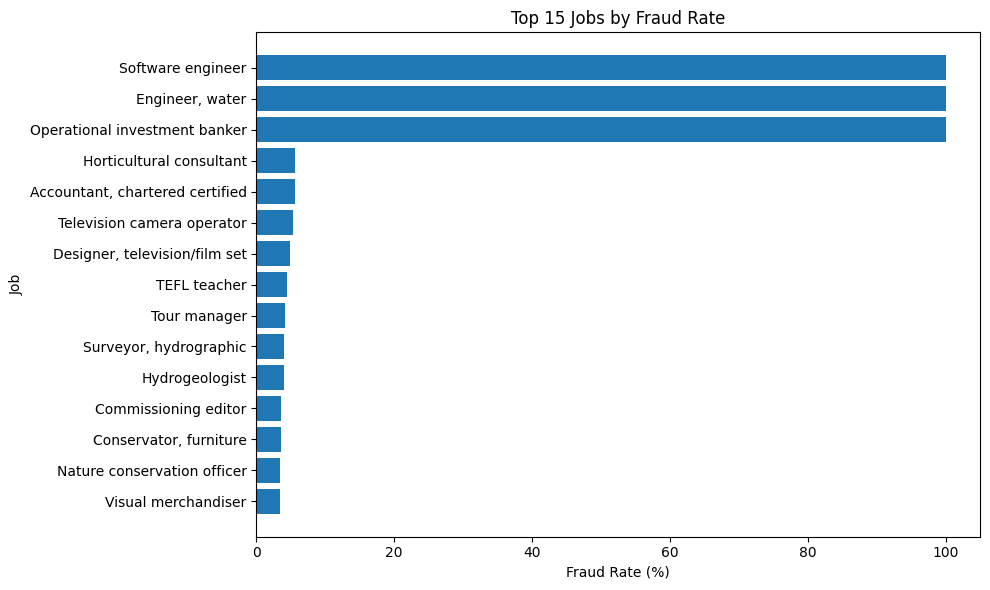

In [51]:
# ============================================================
# Step 19.5: Job-wise Fraud Rate
# ============================================================

job_fraud = (
    pd.crosstab(
        df["job"],
        df["is_fraud"],
        normalize="index"
    ) * 100
)

job_rate = (
    job_fraud[1]
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))

plt.barh(
    job_rate.index[::-1],
    job_rate.values[::-1]
)

plt.title("Top 15 Jobs by Fraud Rate")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Job")
plt.tight_layout()
plt.show()


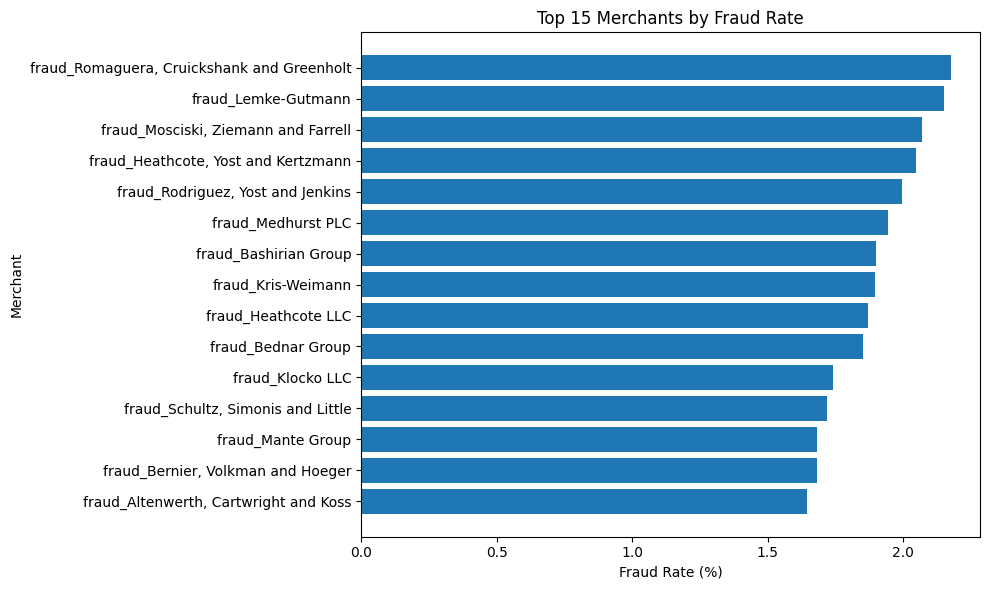

In [52]:
# ============================================================
# Step 19.6: Merchant-wise Fraud Rate
# ============================================================

merchant_fraud = (
    pd.crosstab(
        df["merchant"],
        df["is_fraud"],
        normalize="index"
    ) * 100
)

merchant_rate = (
    merchant_fraud[1]
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))

plt.barh(
    merchant_rate.index[::-1],
    merchant_rate.values[::-1]
)

plt.title("Top 15 Merchants by Fraud Rate")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Merchant")
plt.tight_layout()
plt.show()

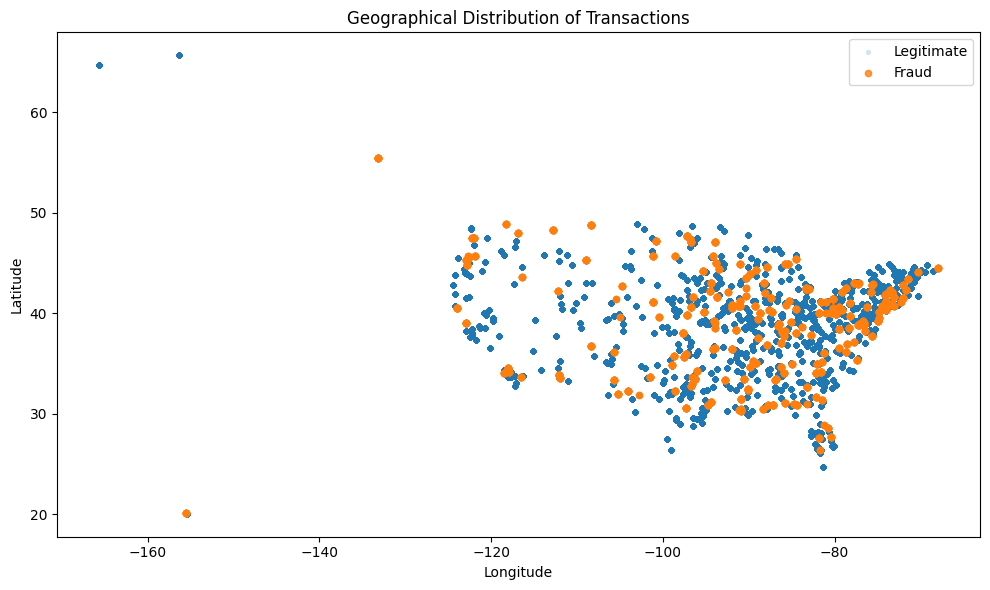

In [53]:
# ============================================================
# Step 20.1: Customer Location Analysis
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df.loc[df["is_fraud"] == 0, "long"],
    df.loc[df["is_fraud"] == 0, "lat"],
    alpha=0.15,
    s=8,
    label="Legitimate"
)

plt.scatter(
    df.loc[df["is_fraud"] == 1, "long"],
    df.loc[df["is_fraud"] == 1, "lat"],
    alpha=0.8,
    s=20,
    label="Fraud"
)

plt.title("Geographical Distribution of Transactions")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()

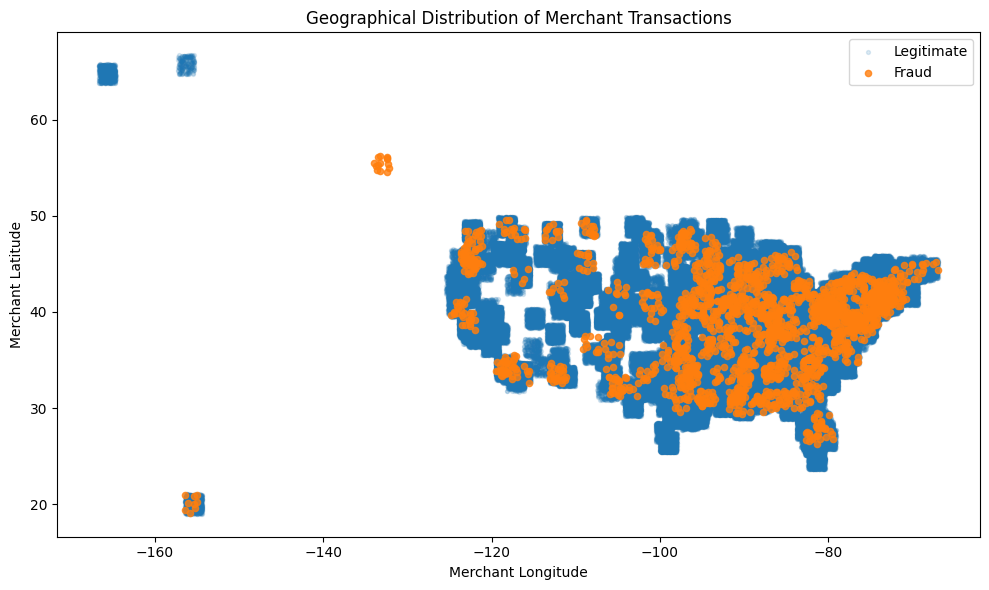

In [54]:
# ============================================================
# Step 20.2: Merchant Location Analysis
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df.loc[df["is_fraud"] == 0, "merch_long"],
    df.loc[df["is_fraud"] == 0, "merch_lat"],
    alpha=0.15,
    s=8,
    label="Legitimate"
)

plt.scatter(
    df.loc[df["is_fraud"] == 1, "merch_long"],
    df.loc[df["is_fraud"] == 1, "merch_lat"],
    alpha=0.8,
    s=20,
    label="Fraud"
)

plt.title("Geographical Distribution of Merchant Transactions")
plt.xlabel("Merchant Longitude")
plt.ylabel("Merchant Latitude")
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
# ============================================================
# Step 20.3: Customer-Merchant Distance
# ============================================================

from numpy import radians, sin, cos, sqrt, arctan2

lat1 = radians(df["lat"])
lon1 = radians(df["long"])
lat2 = radians(df["merch_lat"])
lon2 = radians(df["merch_long"])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = (
    sin(dlat / 2) ** 2
    + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
)

df["distance_km"] = (
    6371 * 2 * arctan2(sqrt(a), sqrt(1 - a))
)

display(
    df.groupby("is_fraud")["distance_km"]
      .agg(["mean", "median", "max"])
)

,mean,median,max
is_fraud,,,
0,76.104480,78.178918,150.922504
1,76.213905,78.593368,142.849901


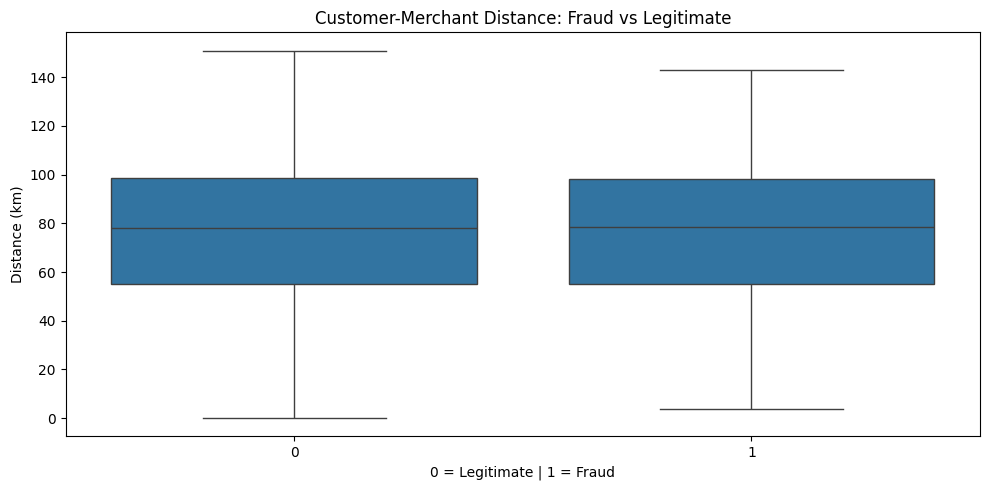

In [56]:
# ============================================================
# Step 20.4: Distance Distribution
# ============================================================

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="distance_km"
)

plt.title("Customer-Merchant Distance: Fraud vs Legitimate")
plt.xlabel("0 = Legitimate | 1 = Fraud")
plt.ylabel("Distance (km)")
plt.tight_layout()
plt.show()

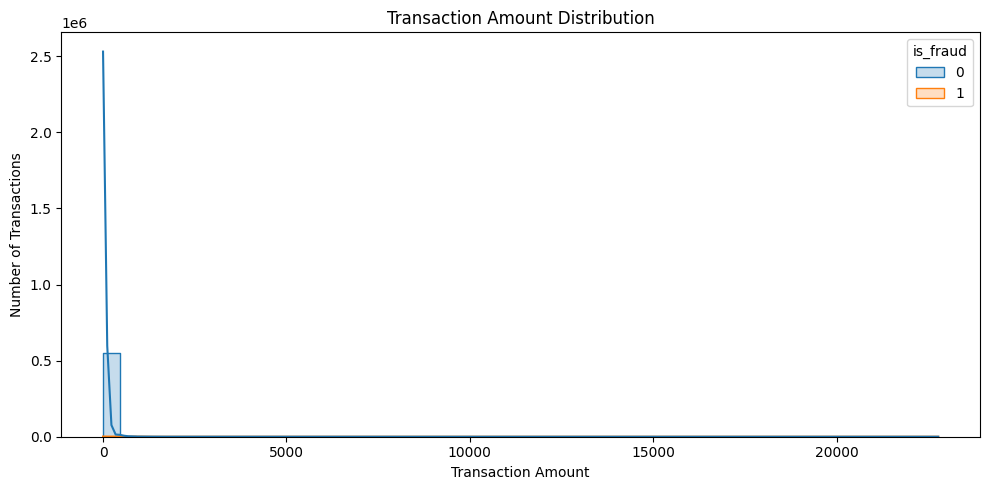

In [57]:
# ============================================================
# Step 21.1: Transaction Amount Distribution
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="amt",
    hue="is_fraud",
    bins=50,
    kde=True,
    element="step"
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

In [58]:
# ============================================================
# Step 21.2: Amount Statistics
# ============================================================

amount_stats = (
    df.groupby("is_fraud")["amt"]
      .agg(["count", "mean", "median", "min", "max", "std"])
)

amount_stats.index = ["Legitimate", "Fraud"]

display(amount_stats)

,count,mean,median,min,max,std
Legitimate,553574,67.614408,47.15,1.00,22768.11,152.471931
Fraud,2145,528.356494,371.94,1.78,1320.92,392.747594


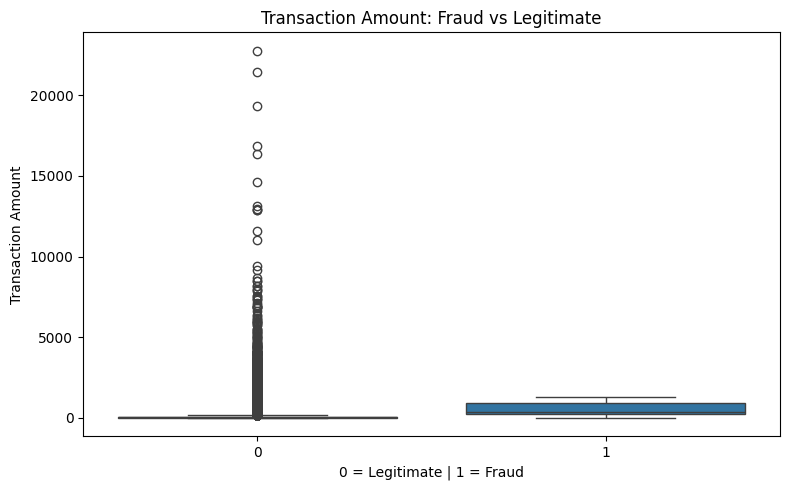

In [59]:
# ============================================================
# Step 21.3: Transaction Amount Comparison
# ============================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="amt"
)

plt.title("Transaction Amount: Fraud vs Legitimate")
plt.xlabel("0 = Legitimate | 1 = Fraud")
plt.ylabel("Transaction Amount")
plt.tight_layout()
plt.show()

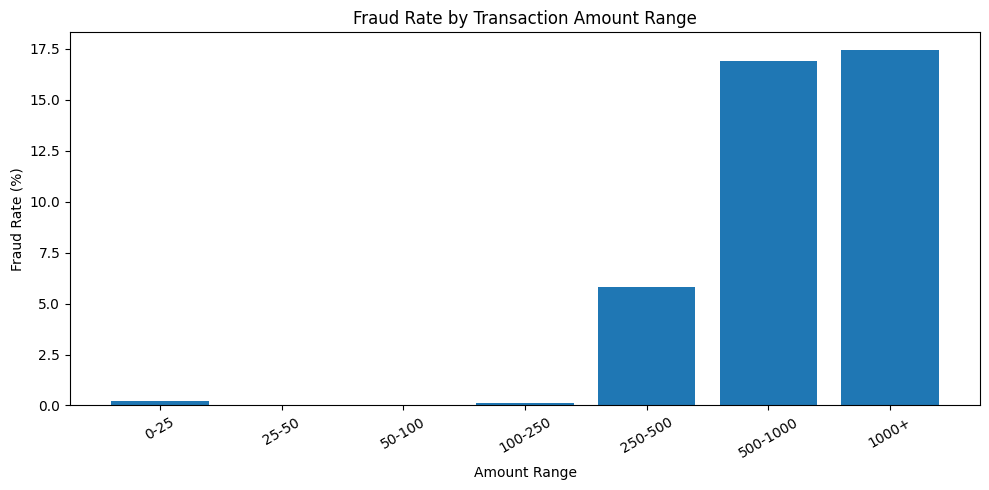

In [60]:
# ============================================================
# Step 21.4: Amount Range vs Fraud Rate
# ============================================================

df["amount_range"] = pd.cut(
    df["amt"],
    bins=[0, 25, 50, 100, 250, 500, 1000, np.inf],
    labels=[
        "0-25",
        "25-50",
        "50-100",
        "100-250",
        "250-500",
        "500-1000",
        "1000+"
    ]
)

amount_fraud = (
    pd.crosstab(
        df["amount_range"],
        df["is_fraud"],
        normalize="index"
    ) * 100
)

plt.figure(figsize=(10, 5))

plt.bar(
    amount_fraud.index.astype(str),
    amount_fraud[1]
)

plt.title("Fraud Rate by Transaction Amount Range")
plt.xlabel("Amount Range")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [61]:
# ============================================================
# Step 22.1: Date & Time Feature Extraction
# ============================================================

# Convert transaction time to datetime
df["trans_date_trans_time"] = pd.to_datetime(
    df["trans_date_trans_time"]
)

# Extract useful time features
df["hour"] = df["trans_date_trans_time"].dt.hour
df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek
df["month"] = df["trans_date_trans_time"].dt.month

# Weekend indicator
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

display(
    df[
        [
            "trans_date_trans_time",
            "hour",
            "day_of_week",
            "month",
            "is_weekend",
            "is_fraud"
        ]
    ].head()
)

,trans_date_trans_time,hour,day_of_week,month,is_weekend,is_fraud
0,2020-06-21 12:14:25,12,6,6,1,0
1,2020-06-21 12:14:33,12,6,6,1,0
2,2020-06-21 12:14:53,12,6,6,1,0
3,2020-06-21 12:15:15,12,6,6,1,0
4,2020-06-21 12:15:17,12,6,6,1,0


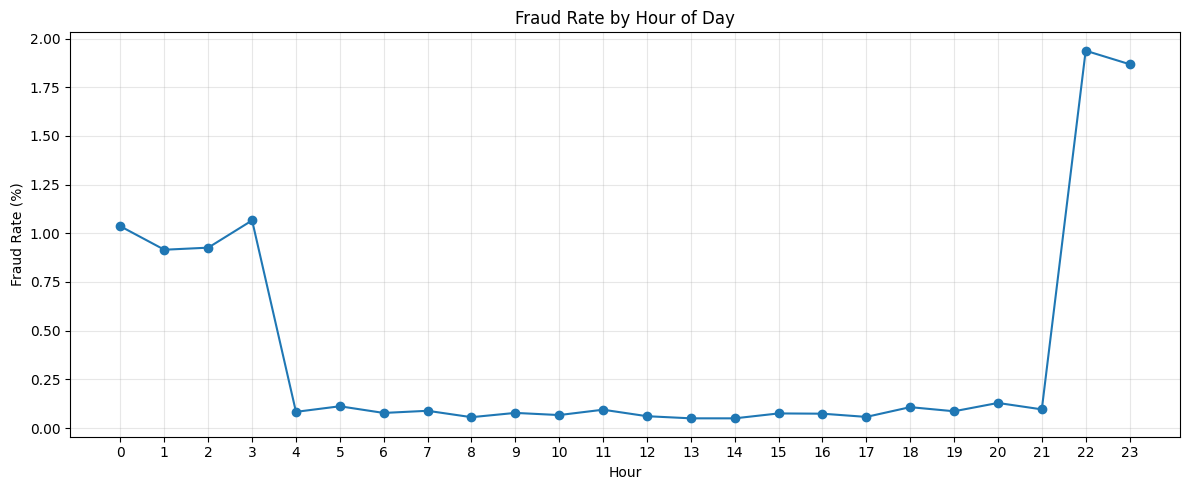

In [62]:
# ============================================================
# Step 22.2: Hour-wise Fraud Rate
# ============================================================

hour_fraud = (
    df.groupby("hour")["is_fraud"]
      .mean()
      .mul(100)
)

plt.figure(figsize=(12, 5))

plt.plot(
    hour_fraud.index,
    hour_fraud.values,
    marker="o"
)

plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

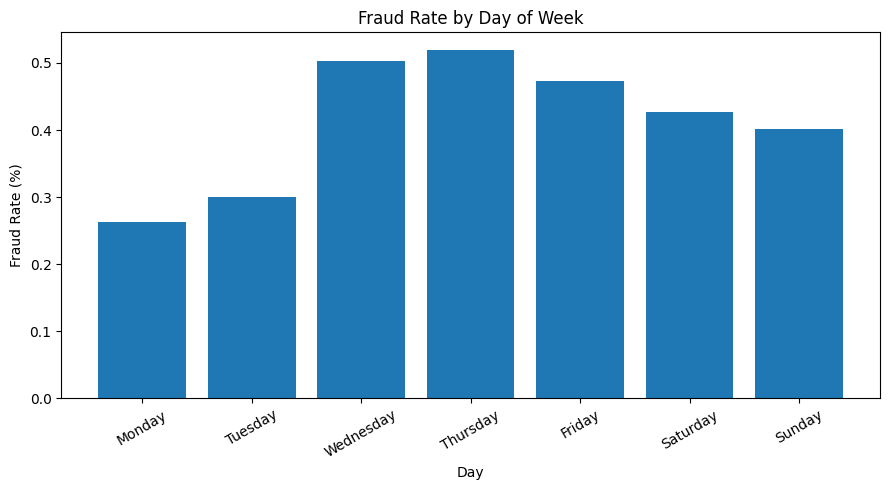

In [63]:
# ============================================================
# Step 22.3: Day-of-Week Fraud Rate
# ============================================================

day_fraud = (
    df.groupby("day_of_week")["is_fraud"]
      .mean()
      .mul(100)
)

day_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(9, 5))

plt.bar(
    day_names,
    day_fraud.values
)

plt.title("Fraud Rate by Day of Week")
plt.xlabel("Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

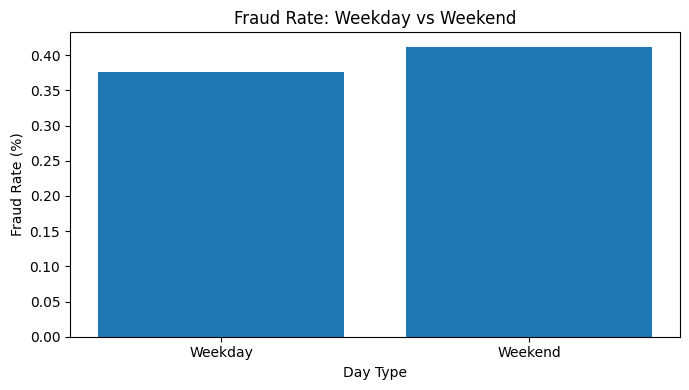

In [64]:
# ============================================================
# Step 22.4: Weekend vs Weekday Fraud
# ============================================================

weekend_fraud = (
    df.groupby("is_weekend")["is_fraud"]
      .mean()
      .mul(100)
)

plt.figure(figsize=(7, 4))

plt.bar(
    ["Weekday", "Weekend"],
    weekend_fraud.values
)

plt.title("Fraud Rate: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

In [65]:
# ============================================================
# Step 23.1: Transaction Frequency Features
# ============================================================

# Number of transactions made by each card
df["card_transaction_count"] = (
    df.groupby("cc_num")["cc_num"]
      .transform("count")
)

# Average transaction amount for each card
df["card_avg_amount"] = (
    df.groupby("cc_num")["amt"]
      .transform("mean")
)

# Difference from card's average spending
df["amount_deviation"] = (
    df["amt"] - df["card_avg_amount"]
)

display(
    df[
        [
            "cc_num",
            "amt",
            "card_transaction_count",
            "card_avg_amount",
            "amount_deviation"
        ]
    ].head()
)

,cc_num,amt,card_transaction_count,card_avg_amount,amount_deviation
0,2291163933867244,2.86,640,61.893062,-59.033062
1,3573030041201292,29.84,837,53.596523,-23.756523
2,3598215285024754,41.28,1073,83.053812,-41.773812
3,3591919803438423,60.05,663,59.207526,0.842474
4,3526826139003047,3.19,891,55.274501,-52.084501


In [66]:
# ============================================================
# Step 23.2: Distance-based Feature
# ============================================================

# Flag unusually large customer-merchant distances
distance_threshold = df["distance_km"].quantile(0.95)

df["large_distance"] = (
    df["distance_km"] > distance_threshold
).astype(int)

print("Distance threshold:", distance_threshold)

display(
    df[
        [
            "distance_km",
            "large_distance",
            "is_fraud"
        ]
    ].head()
)

Distance threshold: 120.51082450392062


,distance_km,large_distance,is_fraud
0,24.561462,0,0
1,104.925092,0,0
2,59.080078,0,0
3,27.698567,0,0
4,104.335106,0,0


In [67]:
# ============================================================
# Step 23.3: Night Transaction Feature
# ============================================================

df["is_night"] = (
    (df["hour"] < 6) |
    (df["hour"] >= 22)
).astype(int)

display(
    df[
        [
            "hour",
            "is_night",
            "is_fraud"
        ]
    ].head(10)
)

,hour,is_night,is_fraud
0,12,0,0
1,12,0,0
2,12,0,0
3,12,0,0
4,12,0,0
5,12,0,0
6,12,0,0
7,12,0,0
8,12,0,0
9,12,0,0


In [68]:
# ============================================================
# Step 23.4: High Amount Indicator
# ============================================================

amount_threshold = df["amt"].quantile(0.95)

df["is_high_amount"] = (
    df["amt"] > amount_threshold
).astype(int)

print("High amount threshold:", amount_threshold)

display(
    df[
        [
            "amt",
            "is_high_amount",
            "is_fraud"
        ]
    ].head()
)

High amount threshold: 193.0509999999998


,amt,is_high_amount,is_fraud
0,2.86,0,0
1,29.84,0,0
2,41.28,0,0
3,60.05,0,0
4,3.19,0,0


In [69]:
# ============================================================
# Step 23.5: Feature Engineering Summary
# ============================================================

new_features = [
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "distance_km",
    "card_transaction_count",
    "card_avg_amount",
    "amount_deviation",
    "large_distance",
    "is_night",
    "is_high_amount"
]

display(df[new_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
hour,555719.0,1.280906e+01,6.810924,0.000000,7.000000,14.000000,19.000000,23.000000
day_of_week,555719.0,2.726779e+00,2.178681,0.000000,1.000000,2.000000,5.000000,6.000000
month,555719.0,9.508536e+00,1.978205,6.000000,8.000000,10.000000,12.000000,12.000000
is_weekend,555719.0,2.795801e-01,0.448793,0.000000,0.000000,0.000000,1.000000,1.000000
distance_km,555719.0,7.610490e+01,29.117079,0.123883,55.286255,78.179517,98.520760,150.922504
card_transaction_count,555719.0,7.814784e+02,323.541973,6.000000,503.000000,821.000000,1057.000000,1474.000000
card_avg_amount,555719.0,6.939281e+01,18.636424,37.594462,57.864812,64.188231,83.051051,859.882000
amount_deviation,555719.0,-1.440216e-16,155.634102,-822.355714,-51.087470,-23.242078,13.443821,22681.733328
large_distance,555719.0,5.000009e-02,0.217945,0.000000,0.000000,0.000000,0.000000,1.000000
is_night,555719.0,2.989478e-01,0.457797,0.000000,0.000000,0.000000,1.000000,1.000000


In [70]:
# ============================================================
# Step 24.4: Potential ID / Leakage Columns
# ============================================================

potential_id_columns = [
    "Unnamed: 0",
    "trans_num",
    "cc_num"
]

existing_id_columns = [
    col for col in potential_id_columns
    if col in df.columns
]

print("Potential ID / sensitive columns:")

for col in existing_id_columns:
    print("-", col)

Potential ID / sensitive columns:
- Unnamed: 0
- trans_num
- cc_num


In [71]:

for col in df.columns:
    if "fraud" in col.lower() or "target" in col.lower():
        print("-", col)

- is_fraud


In [72]:
drop_cols = [
    "is_fraud",
    "trans_num",
    "cc_num",
    "trans_date_trans_time"
]

X = df.drop(columns=drop_cols, errors="ignore")
y = df["is_fraud"]

print(X.shape)

(555719, 33)


In [73]:
cat_cols = X.select_dtypes("object").columns

print(cat_cols.tolist())

['merchant', 'category', 'first', 'last', 'gender', 'street', 'city', 'state', 'job']


C:\Users\Acer\AppData\Local\Temp\ipykernel_8464\3332897534.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes("object").columns


In [74]:
num_cols = X.select_dtypes("number").columns

print(num_cols.tolist())

['Unnamed: 0', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'hour', 'age', 'distance_km', 'day_of_week', 'month', 'is_weekend', 'card_transaction_count', 'card_avg_amount', 'amount_deviation', 'large_distance', 'is_night', 'is_high_amount']


In [75]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(555719, 3848)


In [76]:
print(X.dtypes.value_counts())

bool              3826
int64                9
float64              8
int32                4
datetime64[us]       1
Name: count, dtype: int64


In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(444575, 3848) (111144, 3848)


In [78]:
X.dtypes.value_counts()

bool              3826
int64                9
float64              8
int32                4
datetime64[us]       1
Name: count, dtype: int64

In [79]:
X.isnull().sum()

Unnamed: 0                0
amt                       0
zip                       0
lat                       0
long                      0
                         ..
distance_range_25-50      0
distance_range_50-100     0
distance_range_100-250    0
distance_range_250-500    0
distance_range_500+       0
Length: 3848, dtype: int64

In [80]:
X.isnull().sum().sum()

np.int64(0)

In [81]:
X.shape

(555719, 3848)

In [82]:
from sklearn.model_selection import train_test_split

drop = ["is_fraud", "trans_num", "cc_num", "trans_date_trans_time"]

X = df.drop(columns=drop, errors="ignore")
X = pd.get_dummies(X, drop_first=True)


y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)

(444575, 3848)


In [91]:
from sklearn.model_selection import train_test_split

X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(444575, 36) (111144, 36)


In [94]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


In [93]:
X = df.drop(columns=[
    "is_fraud", "trans_date_trans_time", "dob",
    "merchant", "category", "first", "last",
    "gender", "street", "city", "state", "job",
    "trans_num", "amount_range", "distance_range"
])

y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


In [96]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9982545166630677
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.95      0.58      0.72       429

    accuracy                           1.00    111144
   macro avg       0.97      0.79      0.86    111144
weighted avg       1.00      1.00      1.00    111144



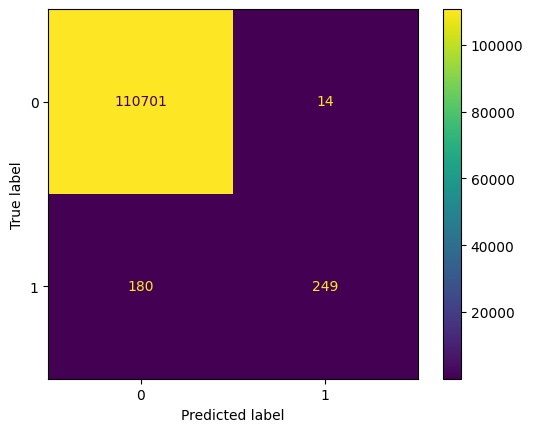

In [97]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()

<Axes: >

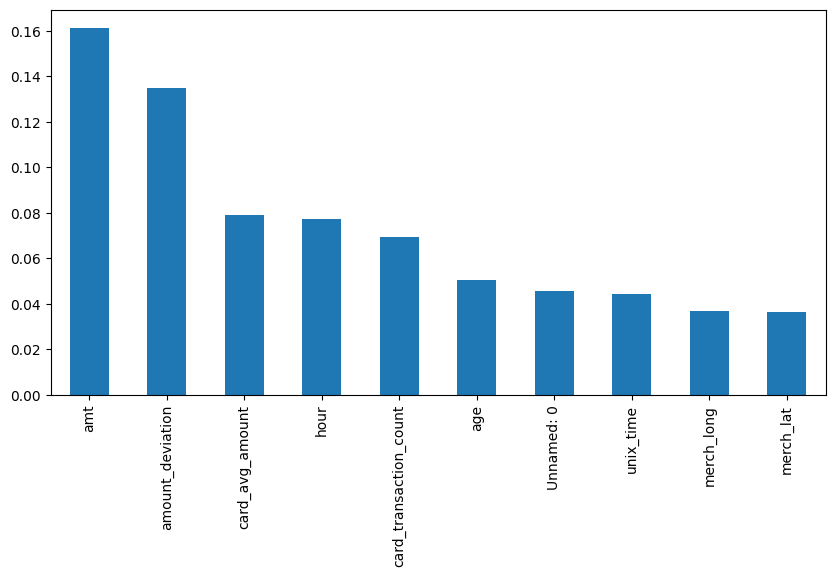

In [98]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(10).plot(kind="bar", figsize=(10,5))

In [99]:
import joblib

joblib.dump(model, "fraud_detection_model.pkl")

print("Model saved successfully!")

Model saved successfully!


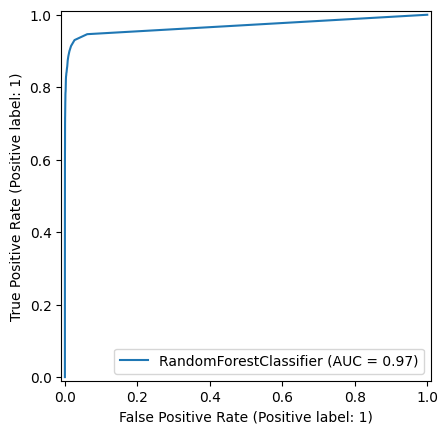

In [101]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test, y_test)

In [102]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.9695192522180737


In [105]:
sample = X_test.iloc[[0]]

prediction = model_balanced.predict(sample)[0]

print("Fraud" if prediction == 1 else "Legitimate")

Legitimate


In [106]:
print("Actual:", y_test.iloc[0])
print("Predicted:", model_balanced.predict(X_test.iloc[[0]])[0])

Actual: 0
Predicted: 0


In [107]:
from sklearn.metrics import recall_score, f1_score

print("Original Recall:", recall_score(y_test, y_pred))
print("Balanced Recall:", recall_score(y_test, y_pred_balanced))

print("Original F1:", f1_score(y_test, y_pred))
print("Balanced F1:", f1_score(y_test, y_pred_balanced))

Original Recall: 0.5804195804195804
Balanced Recall: 0.675990675990676
Original F1: 0.7196531791907514
Balanced F1: 0.7561929595827901


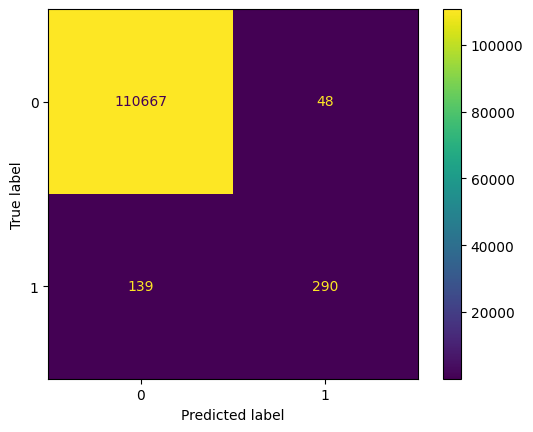

In [108]:
ConfusionMatrixDisplay.from_estimator(
    model_balanced, X_test, y_test
)
